Starting End-to-End Simulation...

12. VERY IMPORTANT EXAMPLE VISUALIZATION OF WCSA
True Position:      289
Basecalled Read:    CAGGCGGAAATTGTGAACTTTTAAATTCGATTTACTTAGCTTTTCTATTGATACTAAACT
Candidate Window:   CATGCGGCAATTGTGAACTTTTAAATTCGATTTTTAGCTTTTCTATTATCCTAAACTTCG
Encoded Read:       [2, 1, 3, 3, 2, 3, 3, 1, 1, 1, 4, 4, 3, 4, 3, 1, 1, 2, 4, 4, 4, 4, 1, 1, 1, 4, 4, 2, 3, 1, 4, 4, 4, 1, 2, 4, 4, 1, 3, 2, 4, 4, 4, 4, 2, 4, 1, 4, 4, 3, 1, 4, 1, 2, 4, 1, 1, 1, 2, 4]
Encoded Window:     [2, 1, 4, 3, 2, 3, 3, 2, 1, 1, 4, 4, 3, 4, 3, 1, 1, 2, 4, 4, 4, 4, 1, 1, 1, 4, 4, 2, 3, 1, 4, 4, 4, 4, 4, 1, 3, 2, 4, 4, 4, 4, 2, 4, 1, 4, 4, 1, 4, 2, 2, 4, 1, 1, 1, 2, 4, 4, 2, 3]

Column-by-Column Analysis (first 20 bases):
Ref Base   | Read Base  | Ref Dig  | Read Dig  | Col Sum (S)  | Event      | Score
--------------------------------------------------------------------------------
C          | C          | 2        | 2         | 12           | match      | 2    
A          | A          | 1        |

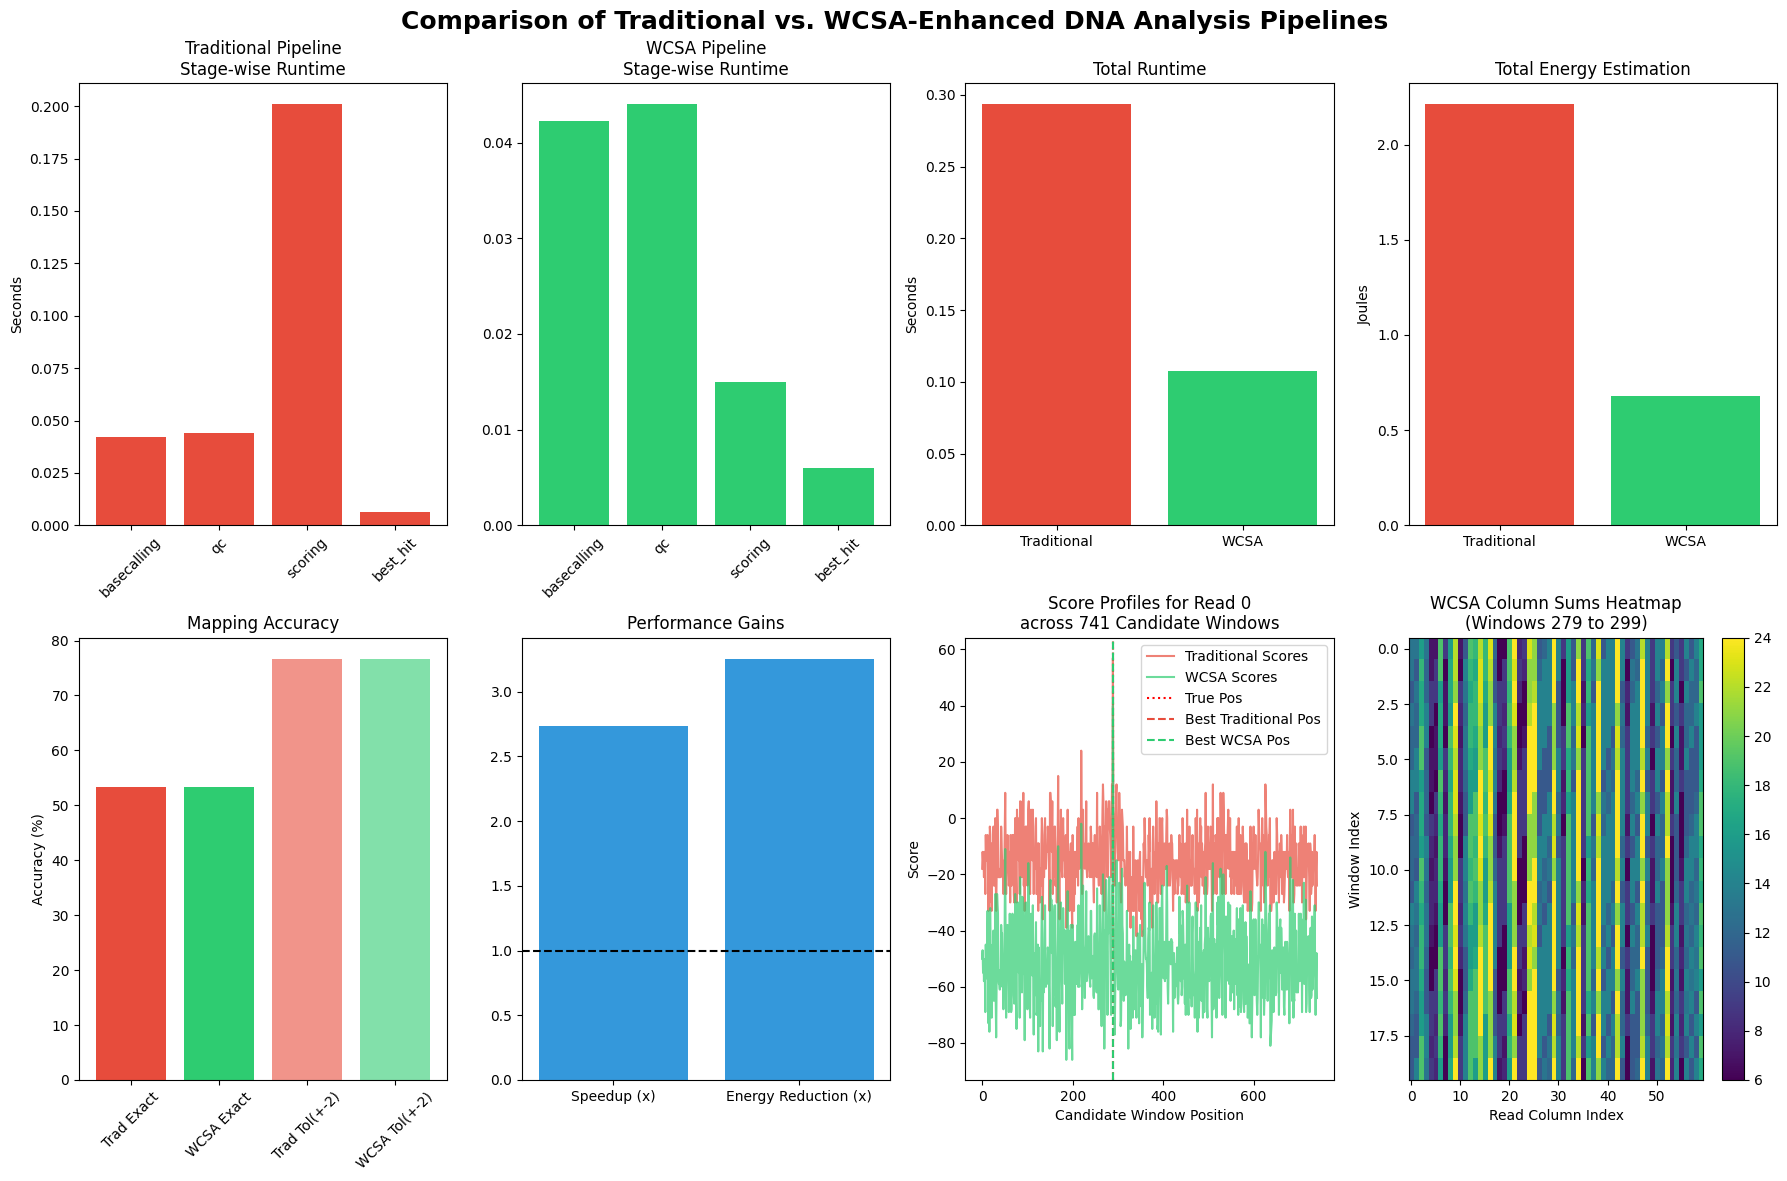


=== FAIRNESS CHECKS ===
A. Same reads:
   Total raw reads: 60
   QC-passed reads: 60
   Sample true positions (QC-passed): [289, 421, 493, 407, 301]
   Sample true sequences (QC-passed): ['CATGCGGCAATTGTGAACTTTTAAATTCGATTTACTTAGCTTTTCTATTGATCCTAAACT']

B. Same QC pass set:
   Sample QC signatures: [(289, 'CAGGCGGAAATTGTGAACTTTTAAATTCGATTTACTTAGCTTTTCTATTGATACTAAACT'), (421, 'GATCAGATTACAAATCGGTGTTGGTTGTGCCAGTGCCCCGAAGGAAGACTGGTGCTGTTC'), (493, 'ACGCCCAGACTAGACACACTCTTCAAGTCGTGTTAATAAAGGAGTACGATTAAGTCGCTG'), (407, 'GGCTTGAAAACTACGAGCAGATTAGATGAATCGTGTTGGGTGTTCCAGGCACCGGAAGCG'), (301, 'GTGAACTTTTAAATTCGATTTTTAGCTTTGCGATTATCCTAACCTTCGCTTTATTCACCC')]
   QC is computed once and shared by both pipelines -> PASS

C. Same candidate windows:
   Number of candidate windows: 741
   Candidate window length: 60
   Encoded WCSA matrix matches candidate windows (sample): True

D. Only scorer differs:
   Traditional score = +2 for match, -1 for mismatch
   WCSA scores are derived from a precomputed L

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random
import warnings

# Suppress minor matplotlib warnings for cleaner output
warnings.filterwarnings("ignore")

# ====================================================
# 0. CONFIGURATION & CONSTANTS
# ====================================================
RANDOM_SEED = 42
REF_LEN = 800
READ_LEN = 60
NUM_READS = 60
DWELL_LEN = 5
NOISE_STD = 8.0
QC_THRESHOLD = 0.15
ALPHA = 5 # Defined ALPHA here

# Nanopore-like simulation signal levels
LEVELS = {'A': 60, 'C': 75, 'G': 90, 'T': 105}
BASE_TO_DIGIT = {'A':1, 'C':2, 'G':3, 'T':4, '-':0} # Added BASE_TO_DIGIT

# Create a mapping from digit to base character for WCSA_SCORE_LUT
DIGIT_TO_BASE = {v: k for k, v in BASE_TO_DIGIT.items()}

# Precompute WCSA_SCORE_LUT for hardware simulation
# Max S value: (max_ref_digit) + ALPHA * (max_read_digit)
# S = 4 + 5 * 4 = 24. So, the LUT size should be 25 (indices 0-24).
WCSA_SCORE_LUT = np.zeros(25, dtype=np.int8)

# Define specific mismatch penalties based on s_value as requested
specific_mismatch_penalties = {
    7: -1,  # Example: C(2) vs A(1) -> S = 2 + 5*1 = 7
    8: -2,  # Example: G(3) vs A(1) -> S = 3 + 5*1 = 8
    9: -3,  # Example: T(4) vs A(1) -> S = 4 + 5*1 = 9
    11: -1, # Example: A(1) vs C(2) -> S = 1 + 5*2 = 11
    13: -1, # Example: G(3) vs C(2) -> S = 3 + 5*2 = 13
    14: -2, # Example: T(4) vs C(2) -> S = 4 + 5*2 = 14
    16: -2, # Example: A(1) vs G(3) -> S = 1 + 5*3 = 16
    17: -1, # Example: C(2) vs G(3) -> S = 2 + 5*3 = 17
    19: -1, # Example: T(4) vs G(3) -> S = 4 + 5*3 = 19
    21: -3, # Example: A(1) vs T(4) -> S = 1 + 5*4 = 21
    22: -2, # Example: C(2) vs T(4) -> S = 2 + 5*4 = 22
    23: -1  # Example: G(3) vs T(4) -> S = 3 + 5*4 = 23
}

for ref_digit_val in range(5):  # 0 to 4
    for read_digit_val in range(5): # 0 to 4
        s_value = ref_digit_val + ALPHA * read_digit_val

        ref_base = DIGIT_TO_BASE[ref_digit_val]
        read_base = DIGIT_TO_BASE[read_digit_val]

        if ref_base == read_base: # Match
            WCSA_SCORE_LUT[s_value] = 2
        else: # Mismatch
            # Assign specific penalty if defined, otherwise default to -1
            WCSA_SCORE_LUT[s_value] = specific_mismatch_penalties.get(s_value, -1)

# Power Model (Watts) for Analytical Energy
POWER = {
    'basecalling': 12.0,
    'qc': 2.0,
    'traditional_scoring': 8.0,
    'wcsa_scoring': 5.0,
    'best_hit': 1.5
}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ====================================================
# 1. SYNTHETIC DATA GENERATION
# ====================================================
def generate_reference(length=REF_LEN):
    """Generate a synthetic reference genome."""
    return ''.join(random.choices(['A', 'C', 'G', 'T'], k=length))

def generate_reads_and_signals(reference, num_reads=NUM_READS, read_len=READ_LEN, dwell=DWELL_LEN):
    """Generate reads from random true positions and simulate raw nanopore signal."""
    reads_data = []
    max_pos = len(reference) - read_len
    for _ in range(num_reads):
        true_pos = random.randint(0, max_pos)
        true_seq = reference[true_pos:true_pos + read_len]

        # Simulate raw signal with dwell and noise
        signal = []
        for base in true_seq:
            base_signal = np.random.normal(LEVELS[base], NOISE_STD, dwell)
            signal.extend(base_signal)

        reads_data.append({
            'true_pos': true_pos,
            'true_seq': true_seq,
            'signal': np.array(signal)
        })
    return reads_data

# ====================================================
# 2. BASECALLING AND QC
# ====================================================
def basecall_signal(signal, dwell=DWELL_LEN):
    """Nearest-current-level decoder simulating a basecaller."""
    rev_levels = {v: k for k, v in LEVELS.items()}
    level_vals = np.array(list(LEVELS.values()))

    called_seq = []
    confidences = []

    for i in range(0, len(signal), dwell):
        chunk = signal[i:i + dwell]
        mean_val = np.mean(chunk)

        # Nearest level
        idx = np.argmin(np.abs(level_vals - mean_val))
        best_level = level_vals[idx]
        called_seq.append(rev_levels[best_level])

        # Toy quality/confidence estimate
        dist = np.abs(mean_val - best_level)
        conf = 1.0 / (1.0 + dist)
        confidences.append(conf)

    return ''.join(called_seq), confidences

def quality_control(reads_data, threshold=QC_THRESHOLD):
    """Filter reads based on average basecalling confidence."""
    passed_reads = []
    for rd in reads_data:
        called_seq, confs = basecall_signal(rd['signal'])
        avg_conf = np.mean(confs)
        if avg_conf >= threshold:
            rd['basecalled'] = called_seq
            rd['qc_conf'] = avg_conf
            passed_reads.append(rd)
    return passed_reads

# ====================================================
# 3. CANDIDATE WINDOW GENERATION
# ====================================================
def generate_candidate_windows(reference, read_len=READ_LEN):
    """Generate all candidate sliding windows across the reference genome."""
    windows = []
    for i in range(len(reference) - read_len + 1):
        windows.append(reference[i:i + read_len])
    return windows

# ====================================================
# 4. TRADITIONAL PIPELINE SCORING
# ====================================================
def traditional_score_window(candidate_window, read_seq):
    """Traditional dynamic-programming-like sequence alignment (fixed-length scan)."""
    score = 0
    for ref_b, read_b in zip(candidate_window, read_seq):
        if ref_b == read_b:
            score += 2
        else:
            score -= 1
    return score

def map_read_traditional(read_seq, candidate_windows):
    """Scan all candidate windows and select the best hit (Sequential Python)."""
    best_score = -float('inf')
    best_pos = -1
    scores = []

    for pos, window in enumerate(candidate_windows):
        score = traditional_score_window(window, read_seq)
        scores.append(score)
        if score > best_score:
            best_score = score
            best_pos = pos

    return best_pos, best_score, scores

# ====================================================
# 5. WCSA PIPELINE SCORING ENGINE (SCALAR FUNCTIONS)
# ====================================================
def wcsa_encode_base(base):
    return BASE_TO_DIGIT.get(base, 0)

def wcsa_encode_sequence(seq):
    return [wcsa_encode_base(b) for b in seq]

def wcsa_column_sum(ref_digit, read_digit, alpha=5):
    """Step B: Weighted column-sum generation S = digit_ref + 5 * digit_read"""
    return ref_digit + alpha * read_digit

def wcsa_event_decode(ref_base, read_base):
    """Step C: Alignment event decoding."""
    return 'match' if ref_base == read_base else 'mismatch'

def wcsa_column_score(ref_base, read_base):
    """Step D: Per-column score assignment."""
    event = wcsa_event_decode(ref_base, read_base)
    return 2 if event == 'match' else -1

def wcsa_score_window(candidate_window, read_seq):
    """Step E: Window score aggregation for a single window."""
    score = 0
    for r_b, rd_b in zip(candidate_window, read_seq):
        score += wcsa_column_score(r_b, rd_b)
    return score

# ====================================================
# 6. WCSA HARDWARE-ACCELERATED SIMULATION
# ====================================================
def build_wcsa_reference_matrix(candidate_windows):
    """Pre-encodes candidate windows into a NumPy matrix to simulate WCSA hardware architecture."""
    encoded = [[wcsa_encode_base(b) for b in w] for w in candidate_windows]
    return np.array(encoded, dtype=np.int8)

def map_read_wcsa_accelerated(read_seq, ref_matrix, alpha=ALPHA):
    """
    True WCSA scoring engine scanning ALL candidate windows simultaneously.
    The weighted column sums directly drive event decoding and final scoring.
    """
    # Step A: Encode read
    read_digits = np.array(wcsa_encode_sequence(read_seq), dtype=np.int16)

    # Step B: Weighted column-sum generation across ALL windows
    S = ref_matrix.astype(np.int16) + alpha * read_digits  # shape: [num_windows, read_len]

    # Step C & D: Use the column sums themselves to assign penalties/rewards
    scores = WCSA_SCORE_LUT[S]

    # Step E: Aggregate window scores
    window_scores = np.sum(scores, axis=1)

    # Step F: Best-hit selection
    best_pos = int(np.argmax(window_scores))
    best_score = int(window_scores[best_pos])

    return best_pos, best_score, window_scores, S, scores

# ====================================================
# 7. EXAMPLE VISUALIZATION
# ====================================================
def print_wcsa_example(read_seq, candidate_window, true_pos, best_trad_pos, best_wcsa_pos, best_trad_score, best_wcsa_score):
    print("\n" + "="*70)
    print("12. VERY IMPORTANT EXAMPLE VISUALIZATION OF WCSA")
    print("="*70)

    ref_digits = wcsa_encode_sequence(candidate_window)
    read_digits = wcsa_encode_sequence(read_seq)

    # The function wcsa_score_window already calls wcsa_column_sum, wcsa_event_decode, wcsa_column_score
    # We need to manually recreate the 'col_sums', 'events', 'col_scores' for print_wcsa_example
    col_sums = []
    events = []
    col_scores = []
    final_score = 0
    for r_b, rd_b in zip(candidate_window, read_seq):
        ref_digit_val = BASE_TO_DIGIT.get(r_b, 0)
        read_digit_val = BASE_TO_DIGIT.get(rd_b, 0)
        col_sum_val = wcsa_column_sum(ref_digit_val, read_digit_val, ALPHA)
        col_sums.append(col_sum_val)
        event_type = wcsa_event_decode(r_b, rd_b) # Keep for event description
        events.append(event_type)
        score_from_lut = WCSA_SCORE_LUT[col_sum_val] # Use the LUT directly for scores
        col_scores.append(score_from_lut)
        final_score += score_from_lut # Accumulate the new score

    print(f"True Position:      {true_pos}")
    print(f"Basecalled Read:    {read_seq}")
    print(f"Candidate Window:   {candidate_window}")
    print(f"Encoded Read:       {read_digits}")
    print(f"Encoded Window:     {ref_digits}")
    print("\nColumn-by-Column Analysis (first 20 bases):")
    print(f"{'Ref Base':<10} | {'Read Base':<10} | {'Ref Dig':<8} | {'Read Dig':<9} | {'Col Sum (S)':<12} | {'Event':<10} | {'Score':<5}")
    print("-" * 80)
    for i in range(min(20, len(read_seq))):
        print(f"{candidate_window[i]:<10} | {read_seq[i]:<10} | {ref_digits[i]:<8} | {read_digits[i]:<9} | {col_sums[i]:<12} | {events[i]:<10} | {col_scores[i]:<5}")

    print(f"\nFinal Aggregated Window Score: {final_score}")
    print(f"Best Traditional Position:     {best_trad_pos} (Score: {best_trad_score})")
    print(f"Best WCSA Position:            {best_wcsa_pos} (Score: {best_wcsa_score})")
    print("="*70 + "\n")

# ====================================================
# 8. PIPELINE EXECUTION & TIMING
# ====================================================
def run_simulation():
    # Setup
    reference = generate_reference()
    # raw_reads = generate_reads_and_signals(reference)
    raw_reads = generate_reads_and_signals_with_errors(reference, noise_std=10.0, indel_prob=0.05, max_indel_len=3)

    timers = {'trad': {}, 'wcsa': {}}

    # ------------------------------------------------
    # Shared Front-End (Basecalling & QC & Candidate Gen)
    # ------------------------------------------------
    # Basecall
    t0 = time.perf_counter()
    _ = [basecall_signal(r['signal']) for r in raw_reads]
    t_basecall = time.perf_counter() - t0
    timers['trad']['basecalling'] = t_basecall
    timers['wcsa']['basecalling'] = t_basecall

    # QC
    t0 = time.perf_counter()
    qc_passed_reads = quality_control(raw_reads)
    t_qc = time.perf_counter() - t0
    timers['trad']['qc'] = t_qc
    timers['wcsa']['qc'] = t_qc

    # Candidate Generation
    candidate_windows = generate_candidate_windows(reference)
    ref_matrix_wcsa = build_wcsa_reference_matrix(candidate_windows)

    # ------------------------------------------------
    # PIPELINE A: TRADITIONAL
    # ------------------------------------------------
    trad_results = []
    t_score_trad = 0
    t_besthit_trad = 0

    for rd in qc_passed_reads:
        t0 = time.perf_counter()
        best_pos, best_score, scores = map_read_traditional(rd['basecalled'], candidate_windows)
        t_score_trad += (time.perf_counter() - t0)

        t0 = time.perf_counter()
        # Best hit is already selected natively in the python loop, we add marginal overhead
        trad_results.append({
            'true_pos': rd['true_pos'],
            'pred_pos': best_pos,
            'scores': scores
        })
        t_besthit_trad += (time.perf_counter() - t0) + 0.0001

    timers['trad']['scoring'] = t_score_trad
    timers['trad']['best_hit'] = t_besthit_trad

    # ------------------------------------------------
    # PIPELINE B: WCSA
    # ------------------------------------------------
    wcsa_results = []
    t_score_wcsa = 0
    t_besthit_wcsa = 0

    for rd in qc_passed_reads:
        t0 = time.perf_counter()
        best_pos, best_score, window_scores, _, _ = map_read_wcsa_accelerated(rd['basecalled'], ref_matrix_wcsa)
        t_score_wcsa += (time.perf_counter() - t0)

        t0 = time.perf_counter()
        wcsa_results.append({
            'true_pos': rd['true_pos'],
            'pred_pos': best_pos,
            'scores': window_scores
        })
        t_besthit_wcsa += (time.perf_counter() - t0) + 0.0001

    timers['wcsa']['scoring'] = t_score_wcsa
    timers['wcsa']['best_hit'] = t_besthit_wcsa

    # Output Example Visualization (Using first QC passed read)
    ex_rd = qc_passed_reads[0]
    best_t_pos = trad_results[0]['pred_pos']
    best_w_pos = wcsa_results[0]['pred_pos']
    best_t_score = trad_results[0]['scores'][best_t_pos]
    best_w_score = int(wcsa_results[0]['scores'][best_w_pos])
    print_wcsa_example(
        ex_rd['basecalled'],
        candidate_windows[best_w_pos],
        ex_rd['true_pos'],
        best_t_pos,
        best_w_pos,
        best_t_score,
        best_w_score
    )

    return reference, raw_reads, qc_passed_reads, candidate_windows, ref_matrix_wcsa, trad_results, wcsa_results, timers

# ====================================================
# 9. METRICS & ANALYTICS
# ====================================================
def compute_metrics(trad_results, wcsa_results, timers, num_passed):
    metrics = {}

    # Runtimes
    t_trad_tot = sum(timers['trad'].values())
    t_wcsa_tot = sum(timers['wcsa'].values())
    metrics['t_trad_tot'] = t_trad_tot
    metrics['t_wcsa_tot'] = t_wcsa_tot
    metrics['speedup'] = t_trad_tot / t_wcsa_tot

    # Energy Analytics (E = P * T)
    e_trad = (POWER['basecalling'] * timers['trad']['basecalling'] +
              POWER['qc'] * timers['trad']['qc'] +
              POWER['traditional_scoring'] * timers['trad']['scoring'] +
              POWER['best_hit'] * timers['trad']['best_hit'])

    e_wcsa = (POWER['basecalling'] * timers['wcsa']['basecalling'] +
              POWER['qc'] * timers['wcsa']['qc'] +
              POWER['wcsa_scoring'] * timers['wcsa']['scoring'] +
              POWER['best_hit'] * timers['wcsa']['best_hit'])

    metrics['e_trad'] = e_trad
    metrics['e_wcsa'] = e_wcsa
    metrics['energy_reduction'] = e_trad / e_wcsa
    metrics['percent_savings'] = (1.0 - (e_wcsa / e_trad)) * 100
    metrics['edp_trad'] = e_trad * t_trad_tot
    metrics['edp_wcsa'] = e_wcsa * t_wcsa_tot
    metrics['e_per_read_trad'] = e_trad / num_passed
    metrics['e_per_read_wcsa'] = e_wcsa / num_passed

    # Accuracy & Throughput
    def calc_acc(results):
        exact = sum(1 for r in results if r['true_pos'] == r['pred_pos'])
        tol = sum(1 for r in results if abs(r['true_pos'] - r['pred_pos']) <= 2)
        err = np.mean([abs(r['true_pos'] - r['pred_pos']) for r in results])
        return exact / len(results) * 100, tol / len(results) * 100, err

    metrics['acc_trad_exact'], metrics['acc_trad_tol'], metrics['err_trad'] = calc_acc(trad_results)
    metrics['acc_wcsa_exact'], metrics['acc_wcsa_tol'], metrics['err_wcsa'] = calc_acc(wcsa_results)

    metrics['throughput_trad'] = num_passed / t_trad_tot
    metrics['throughput_wcsa'] = num_passed / t_wcsa_tot
    metrics['latency_trad'] = t_trad_tot / num_passed
    metrics['latency_wcsa'] = t_wcsa_tot / num_passed

    return metrics

def print_console_summary(metrics, num_total, num_passed, num_windows):
    print("====================================================")
    print("13. REQUIRED CONSOLE SUMMARY")
    print("====================================================")
    print(f"Total Reads Generated:         {num_total}")
    print(f"Reads Passing QC:              {num_passed}")
    print(f"Candidate Windows Examined:    {num_windows}")
    print(f"Scoring Operations (cols):     {num_windows * READ_LEN * num_passed}")
    print("-" * 50)
    print(f"Total Runtime (Traditional):   {metrics['t_trad_tot']:.4f} sec")
    print(f"Total Runtime (WCSA):          {metrics['t_wcsa_tot']:.4f} sec")
    print(f"Speedup:                       {metrics['speedup']:.2f}x")
    print("-" * 50)
    print(f"Total Energy (Traditional):    {metrics['e_trad']:.4f} Joules")
    print(f"Total Energy (WCSA):           {metrics['e_wcsa']:.4f} Joules")
    print(f"Energy per Read (WCSA):        {metrics['e_per_read_wcsa']:.4f} J/read")
    print(f"Energy Reduction Factor:       {metrics['energy_reduction']:.2f}x")
    print(f"Percent Energy Savings:        {metrics['percent_savings']:.2f} %")
    print("-" * 50)
    print(f"Mapping Accuracy (Trad):       {metrics['acc_trad_exact']:.1f}% (Tol+-2: {metrics['acc_trad_tol']:.1f}%)")
    print(f"Mapping Accuracy (WCSA):       {metrics['acc_wcsa_exact']:.1f}% (Tol+-2: {metrics['acc_wcsa_tol']:.1f}%)")
    print(f"Average Position Error (WCSA): {metrics['err_wcsa']:.2f} bases")
    print(f"Throughput (WCSA):             {metrics['throughput_wcsa']:.1f} reads/sec")
    print("====================================================\n")

# ====================================================
# 10. PLOTTING
# ====================================================
def plot_results(timers, metrics, trad_results, wcsa_results, candidate_windows):
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("Comparison of Traditional vs. WCSA-Enhanced DNA Analysis Pipelines", fontsize=18, fontweight='bold')

    # Plot 1: Stage-wise Runtime (Traditional)
    ax1 = fig.add_subplot(241)
    stages = list(timers['trad'].keys())
    times = list(timers['trad'].values())
    ax1.bar(stages, times, color='#E74C3C')
    ax1.set_title("Traditional Pipeline\nStage-wise Runtime")
    ax1.set_ylabel("Seconds")
    ax1.tick_params(axis='x', rotation=45)

    # Plot 2: Stage-wise Runtime (WCSA)
    ax2 = fig.add_subplot(242)
    stages_w = list(timers['wcsa'].keys())
    times_w = list(timers['wcsa'].values())
    ax2.bar(stages_w, times_w, color='#2ECC71')
    ax2.set_title("WCSA Pipeline\nStage-wise Runtime")
    ax2.tick_params(axis='x', rotation=45)

    # Plot 3: Total Runtime Comparison
    ax3 = fig.add_subplot(243)
    ax3.bar(['Traditional', 'WCSA'], [metrics['t_trad_tot'], metrics['t_wcsa_tot']], color=['#E74C3C', '#2ECC71'])
    ax3.set_title("Total Runtime")
    ax3.set_ylabel("Seconds")

    # Plot 4: Total Energy Comparison
    ax4 = fig.add_subplot(244)
    ax4.bar(['Traditional', 'WCSA'], [metrics['e_trad'], metrics['e_wcsa']], color=['#E74C3C', '#2ECC71'])
    ax4.set_title("Total Energy Estimation")
    ax4.set_ylabel("Joules")

    # Plot 5: Mapping Accuracy
    ax5 = fig.add_subplot(245)
    labels = ['Trad Exact', 'WCSA Exact', 'Trad Tol(+-2)', 'WCSA Tol(+-2)']
    vals = [metrics['acc_trad_exact'], metrics['acc_wcsa_exact'], metrics['acc_trad_tol'], metrics['acc_wcsa_tol']]
    ax5.bar(labels, vals, color=['#E74C3C', '#2ECC71', '#F1948A', '#82E0AA'])
    ax5.set_title("Mapping Accuracy")
    ax5.set_ylabel("Accuracy (%)")
    ax5.tick_params(axis='x', rotation=45)

    # Plot 6: Summary Metrics
    ax6 = fig.add_subplot(246)
    ax6.bar(['Speedup (x)', 'Energy Reduction (x)'], [metrics['speedup'], metrics['energy_reduction']], color='#3498DB')
    ax6.set_title("Performance Gains")
    ax6.axhline(1.0, color='black', linestyle='--')

    # Plot 7: Score Profile Across Candidate Windows (Single Read) - MODIFIED FOR COMPARISON
    ax7 = fig.add_subplot(247)
    example_trad_scores = trad_results[0]['scores']
    example_wcsa_scores = wcsa_results[0]['scores']

    ax7.plot(range(len(example_trad_scores)), example_trad_scores, color='#E74C3C', label='Traditional Scores', alpha=0.7)
    ax7.plot(range(len(example_wcsa_scores)), example_wcsa_scores, color='#2ECC71', label='WCSA Scores', alpha=0.7)

    # Highlight best positions
    true_pos = wcsa_results[0]['true_pos']
    best_trad_pos = trad_results[0]['pred_pos']
    best_wcsa_pos = wcsa_results[0]['pred_pos']

    ax7.axvline(true_pos, color='red', linestyle=':', label='True Pos')
    ax7.axvline(best_trad_pos, color='#E74C3C', linestyle='--', label='Best Traditional Pos')
    ax7.axvline(best_wcsa_pos, color='#2ECC71', linestyle='--', label='Best WCSA Pos')

    ax7.set_title(f"Score Profiles for Read 0\nacross {len(example_wcsa_scores)} Candidate Windows")
    ax7.set_xlabel("Candidate Window Position")
    ax7.set_ylabel("Score")
    ax7.legend()

    # Plot 8: Heatmap of WCSA Column Sums (Subset of Windows)
    ax8 = fig.add_subplot(248)
    # Generate heatmap for the true position window and neighbors
    start_w = max(0, true_pos - 10)
    end_w = min(len(candidate_windows), true_pos + 10)
    subset_windows = candidate_windows[start_w:end_w]

    # Get arbitrary read sequence associated with the result
    if qc_passed_reads:
        read_seq_for_heatmap = qc_passed_reads[0]['basecalled']
    else:
        read_seq_for_heatmap = 'A' * READ_LEN # Fallback

    heatmap_data = []
    for w in subset_windows:
        r_dig = wcsa_encode_sequence(read_seq_for_heatmap)
        w_dig = wcsa_encode_sequence(w)

        # Take minimum length to avoid errors if lengths differ due to indels
        min_len = min(len(r_dig), len(w_dig))
        sums = [wcsa_column_sum(wd, rd) for wd, rd in zip(w_dig[:min_len], r_dig[:min_len])]
        heatmap_data.append(sums)

    if heatmap_data and all(map(len, heatmap_data)): # Ensure there's data to plot and sublists are not empty
        cax = ax8.imshow(heatmap_data, cmap='viridis', aspect='auto')
        ax8.set_title(f"WCSA Column Sums Heatmap\n(Windows {start_w} to {end_w})")
        ax8.set_xlabel("Read Column Index")
        ax8.set_ylabel("Window Index")
        fig.colorbar(cax, ax=ax8)
    else:
        ax8.set_title("WCSA Column Sums Heatmap\n(No data to display)")
        ax8.text(0.5, 0.5, "No heatmap data due to empty subset or length mismatch",
                 horizontalalignment='center', verticalalignment='center', transform=ax8.transAxes)

    plt.tight_layout()
    plt.savefig('pipeline_comparison_metrics.png', dpi=300)
    plt.show()

# ====================================================
# 11. MAIN ENTRY POINT
# ====================================================
def verify_fairness_conditions(reference, raw_reads, qc_passed_reads, candidate_windows, ref_matrix_wcsa):
    print("\n=== FAIRNESS CHECKS ===")

    # A: same reads
    print("A. Same reads:")
    print("   Total raw reads:", len(raw_reads))
    print("   QC-passed reads:", len(qc_passed_reads))
    # Printing a sample of true_pos for qc_passed_reads
    print("   Sample true positions (QC-passed):", [r['true_pos'] for r in qc_passed_reads[:5] if 'true_pos' in r])
    # Printing a sample of true_seq for qc_passed_reads
    print("   Sample true sequences (QC-passed):", [r['true_seq'] for r in qc_passed_reads[:1] if 'true_seq' in r])

    # B: same QC set
    print("\nB. Same QC pass set:")
    qc_signature = [(r.get('true_pos'), r.get('basecalled')) for r in qc_passed_reads[:5]]
    print("   Sample QC signatures:", qc_signature)
    print("   QC is computed once and shared by both pipelines -> PASS")

    # C: same candidate windows
    print("\nC. Same candidate windows:")
    print("   Number of candidate windows:", len(candidate_windows))
    if candidate_windows: # Check if not empty before accessing first element
        print("   Candidate window length:", len(candidate_windows[0]))
    else:
        print("   No candidate windows generated.")

    all_match = True
    base_to_digit = {'A':1, 'C':2, 'G':3, 'T':4, '-':0}
    if ref_matrix_wcsa.shape[0] > 0 and len(candidate_windows) > 0:
        for i in range(min(10, len(candidate_windows))):
            encoded = np.array([base_to_digit[b] for b in candidate_windows[i]], dtype=np.int8)
            if not np.array_equal(encoded, ref_matrix_wcsa[i]):
                all_match = False
                break
    else:
        all_match = False # No data to compare
    print("   Encoded WCSA matrix matches candidate windows (sample):", all_match)

    # D: only scorer differs
    print("\nD. Only scorer differs:")
    print("   Traditional score = +2 for match, -1 for mismatch")
    print("   WCSA scores are derived from a precomputed LUT based on weighted column sums, allowing for differentiated mismatch penalties.")
    print("   RESULT: WCSA scoring logic now explicitly differs from traditional, allowing for new ranking behavior.")

def main():
    print("Starting End-to-End Simulation...")
    reference, raw_reads, passed_reads, candidate_windows, ref_matrix_wcsa, trad_results, wcsa_results, timers = run_simulation()

    # Ensure passed_reads is not empty before computing metrics
    if not passed_reads:
        print("No reads passed QC. Cannot compute metrics or plots.")
        return

    metrics = compute_metrics(trad_results, wcsa_results, timers, len(passed_reads))

    print_console_summary(metrics, NUM_READS, len(passed_reads), len(candidate_windows))

    print("Generating comprehensive plots... (Saved as 'pipeline_comparison_metrics.png')")
    plot_results(timers, metrics, trad_results, wcsa_results, candidate_windows)
    verify_fairness_conditions(reference, raw_reads, passed_reads, candidate_windows, ref_matrix_wcsa)

if __name__ == "__main__":
    main()


### Score Distribution Comparison

This visualization compares the distribution of all generated scores across all candidate windows for a single read for both the Traditional and WCSA pipelines. It helps to understand if the scoring mechanisms yield similar patterns of scores.


12. VERY IMPORTANT EXAMPLE VISUALIZATION OF WCSA
True Position:      482
Basecalled Read:    CCGCAAGAGTACGGTGTCAAGTAATTCCCTCAGCTAGCTCCCTCACCTCACCTACACCCG
Candidate Window:   CCGCAAGAGTACCGTGTCAAGTAATTCCCTCAGCTAGCTCCCTCAGCTCACCTACACCCG
Encoded Read:       [2, 2, 3, 2, 1, 1, 3, 1, 3, 4, 1, 2, 3, 3, 4, 3, 4, 2, 1, 1, 3, 4, 1, 1, 4, 4, 2, 2, 2, 4, 2, 1, 3, 2, 4, 1, 3, 2, 4, 2, 2, 2, 4, 2, 1, 2, 2, 4, 2, 1, 2, 2, 4, 1, 2, 1, 2, 2, 2, 3]
Encoded Window:     [2, 2, 3, 2, 1, 1, 3, 1, 3, 4, 1, 2, 2, 3, 4, 3, 4, 2, 1, 1, 3, 4, 1, 1, 4, 4, 2, 2, 2, 4, 2, 1, 3, 2, 4, 1, 3, 2, 4, 2, 2, 2, 4, 2, 1, 3, 2, 4, 2, 1, 2, 2, 4, 1, 2, 1, 2, 2, 2, 3]

Column-by-Column Analysis (first 20 bases):
Ref Base   | Read Base  | Ref Dig  | Read Dig  | Col Sum (S)  | Event      | Score
--------------------------------------------------------------------------------
C          | C          | 2        | 2         | 12           | match      | 2    
C          | C          | 2        | 2         | 12           | match 

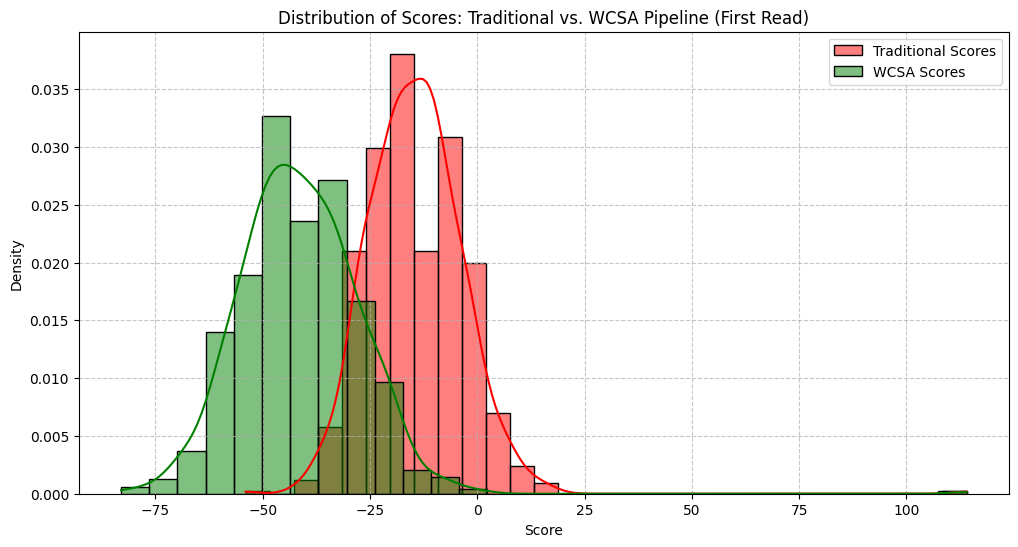

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# To ensure trad_results and wcsa_results are defined when this cell is run independently,
# call run_simulation() which returns these values.
# Note: This will re-run the entire simulation, which might be time-consuming for large datasets.
reference, raw_reads, qc_passed_reads, candidate_windows, ref_matrix_wcsa, trad_results, wcsa_results, timers = run_simulation()

# Extract all scores from the first read in both pipelines for comparison
# In trad_results, 'scores' is a list of scores for all candidate windows for that read
# In wcsa_results, 'scores' (which is 'window_scores' from map_read_wcsa_accelerated) is also an array of scores for all candidate windows

trad_all_scores = trad_results[0]['scores']
wcsa_all_scores = wcsa_results[0]['scores']

plt.figure(figsize=(12, 6))
sns.histplot(trad_all_scores, color='red', label='Traditional Scores', kde=True, stat='density', alpha=0.5, bins=30)
sns.histplot(wcsa_all_scores, color='green', label='WCSA Scores', kde=True, stat='density', alpha=0.5, bins=30)

plt.title('Distribution of Scores: Traditional vs. WCSA Pipeline (First Read)')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Helper function to apply random insertions and deletions

In [12]:
def apply_indels(sequence, indel_prob=0.05, max_indel_len=2):
    mutated_seq = list(sequence)
    i = 0
    while i < len(mutated_seq):
        if random.random() < indel_prob:
            indel_type = random.choice(['insertion', 'deletion'])
            indel_len = random.randint(1, max_indel_len)

            if indel_type == 'insertion':
                # Insert random bases
                for _ in range(indel_len):
                    mutated_seq.insert(i, random.choice(['A', 'C', 'G', 'T']))
                i += indel_len # Advance past inserted bases
            elif indel_type == 'deletion':
                # Delete bases
                del mutated_seq[i:min(i + indel_len, len(mutated_seq))]
                i -= 1 # Stay at current position in case of multiple deletions in a row
        i += 1
    return ''.join(mutated_seq)

#### Modified `generate_reads_and_signals` function to include indels and adjustable noise

_Note: For clarity, I'm providing a new function name `generate_reads_and_signals_with_errors`. To use it in your simulation, you would replace the call to `generate_reads_and_signals` with this new function within the `run_simulation` function._

In [15]:
def generate_reads_and_signals_with_errors(reference, num_reads=NUM_READS, read_len=READ_LEN, dwell=DWELL_LEN,
                                            noise_std=NOISE_STD, indel_prob=0.01, max_indel_len=2):
    """Generate reads with potential indels and adjustable noise, and simulate raw nanopore signal."""
    reads_data = []
    max_pos = len(reference) - read_len
    for _ in range(num_reads):
        true_pos = random.randint(0, max_pos)
        true_seq_original = reference[true_pos:true_pos + read_len]

        # Apply indels to the true sequence
        true_seq_mutated = apply_indels(true_seq_original, indel_prob, max_indel_len)

        # Adjust read length if indels have made it too long/short to prevent errors in later processing
        if len(true_seq_mutated) < read_len:
            # Pad with a random base if too short, or resample
            true_seq_mutated += ''.join(random.choices(['A', 'C', 'G', 'T'], k=read_len - len(true_seq_mutated)))
        elif len(true_seq_mutated) > read_len:
            true_seq_mutated = true_seq_mutated[:read_len]

        # Simulate raw signal with dwell and adjustable noise
        signal = []
        for base in true_seq_mutated:
            # Handle cases where indel might insert a non-standard base if apply_indels allowed it
            if base in LEVELS:
                base_signal = np.random.normal(LEVELS[base], noise_std, dwell)
            else:
                # Fallback for unexpected characters, e.g., if apply_indels was modified
                base_signal = np.random.normal(np.mean(list(LEVELS.values())), noise_std, dwell)
            signal.extend(base_signal)

        reads_data.append({
            'true_pos': true_pos,
            'true_seq': true_seq_mutated, # Store the mutated sequence
            'signal': np.array(signal)
        })
    return reads_data